# High-throughput assessment of blueberry fruit internal bruising — published inference pipeline

**Paper:** Chenjiao Tan, Changying Li, Penelope Perkins-Veazie, Heeduk Oh, Rui Xu, Massimo Iorizzo.
*High throughput assessment of blueberry fruit internal bruising using deep learning models.*
Frontiers in Plant Science 16:1575038 (2025). doi:[10.3389/fpls.2025.1575038](https://doi.org/10.3389/fpls.2025.1575038) (open access, CC BY)

**Author code & models:** Hugging Face Space [`c-tan/blueberrybruisingdet`](https://huggingface.co/spaces/c-tan/blueberrybruisingdet) (Space license: CC BY-NC 4.0), maintained by the first author. This notebook re-runs the Space's published inference pipeline headlessly with the author's own `app.py` functions.

**Scope (executed demonstration):** on **one author-provided example image**, run the three-model pipeline of the paper's Sections 2.4–2.5: (1) YOLOv8 detection of individual berries, (2) YOLOv8-seg fruit cross-section segmentation, (3) YOLO11-seg internal-bruise segmentation, then compute each berry's **bruising ratio = bruise pixel area / fruit pixel area** — the quantity the paper's Section 3.3 validates (YOLO11: MAE 0.025, MAPE 15.87%) and Section 3.3/3.4 analyses build on.

**Out of scope:** model training, dataset-level evaluation (the 185/162/676–1001-image datasets are not publicly archived — data available from authors on request), k-means/firmness analyses (no public numeric tables), and the Gradio web UI (chrome omitted; its exact processing function is reproduced below).

**日本語概要:** 本ノートブックは、論文著者自身の HF Space（`c-tan/blueberrybruisingdet`）が公開している推論パイプラインを、そのままの関数コードで 1 枚の提供例画像に対して実行します。YOLOv8 による果実検出 → YOLOv8-seg による果実断面セグメンテーション → YOLO11-seg による内部褐変（bruisng）セグメンテーションを行い、果実ごとの「褐変面積比率」を算出します。学習・データセット評価は範囲外です。

**Execution status:** this notebook must be run top-to-bottom in a fresh runtime (Run all). CPU works (the author's Space itself runs on CPU); a T4 GPU is recommended and only changes device placement.

## 1. Runtime selection and Run all

**Runtime →** `Runtime > Change runtime type`. Recommended: **T4 GPU** (fastest). A standard **CPU** runtime also runs the full pipeline faithfully — the author's own Space serves this pipeline on CPU.

Expected wall time and downloads (estimates; verify in outputs): dependency install ≈ 1–3 min; downloads ≈ 71 MB (3 weight files + 1 example image); inference ≈ 1–5 min on CPU, <1 min on GPU. All downloads happen inside this notebook into `/content`; nothing is fetched from DGX or Drive.

**日本語:** 「ランタイム → ランタイムのタイプを変更」で T4 GPU を推奨（CPU でも動作します）。セットアップ約 1–3 分、ダウンロード約 71 MB、推論は CPU で数分・GPU では 1 分未満の見込みです。すべてのダウンロードはこのノートブック内で `/content` に行われます。

In [ ]:
import platform, sys
import torch

print("Python:", platform.python_version())
print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    DEVICE = "cuda:0"
else:
    print("Device: CPU")
    DEVICE = "cpu"


Python: 3.13.16
torch: 2.11.0+cpu
CUDA available: False
Device: CPU


**Cell role:** report the runtime hardware and select the torch device once (`DEVICE`). Only device placement branches between CPU/GPU — the sample, weights, parameters and calculations are identical.

**日本語:** 実行環境のハードウェアを確認し、推論デバイス `DEVICE` を 1 回だけ決定します。CPU/GPU で変わるのはデバイス配置のみです。

In [ ]:
%pip install -q "ultralytics>=8.4.60"
import ultralytics
print("ultralytics:", ultralytics.__version__)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 684.8 kB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 4.3 MB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 8.2 MB/s eta 0:00:00


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


ultralytics: 8.4.174


## 2. Dependencies

Install the author's pinned inference stack. The Space's `requirements.txt` requires `ultralytics>=8.4.60` (the paper trained with ultralytics 8.3.3 / PyTorch 2.4.1; the checkpoints pickle-load `ultralytics.nn.*`, which current ultralytics supports — verified below at weight-load time). `torch`/`opencv`/`matplotlib`/`numpy`/`pandas` are preinstalled on Colab. Gradio (GUI chrome) is intentionally not installed.

**日本語:** 著者の `requirements.txt` に従い `ultralytics>=8.4.60` をインストールします（Gradio の UI 部分は不要のため省略）。重み読み込み時にピクル互換性が検証されます。

In [ ]:
import hashlib, urllib.request
from pathlib import Path

DATA_DIR = Path("/content/blueberry_bruising")
DATA_DIR.mkdir(parents=True, exist_ok=True)
SPACE = "https://huggingface.co/spaces/c-tan/blueberrybruisingdet"

# name -> (expected bytes, sha256) recorded from the HF Space file tree API on 2026-10-07
ASSETS = {
    "example.png": (3_580_989, "4669e068015e63950c96469e19e89806fcdb53736ec9c5bb5015f3301aca6e8b"),
}

def fetch(name, expected_size, expected_sha):
    dest = DATA_DIR / name
    url = f"{SPACE}/resolve/main/{name}"
    if not dest.exists() or dest.stat().st_size != expected_size:
        print(f"downloading {url}")
        urllib.request.urlretrieve(url, dest)  # public asset, no token
    data = dest.read_bytes()
    assert len(data) == expected_size, f"{name}: size {len(data)} != {expected_size}"
    digest = hashlib.sha256(data).hexdigest()
    assert digest == expected_sha, f"{name}: sha256 mismatch"
    print(f"OK {name}: {len(data):,} bytes, sha256 verified")
    return dest

example_path = fetch("example.png", *ASSETS["example.png"])


downloading https://huggingface.co/spaces/c-tan/blueberrybruisingdet/resolve/main/example.png


OK example.png: 3,580,989 bytes, sha256 verified


## 3. Minimal input acquisition with provenance

Download the author's example photograph `example.png` from the pinned Hugging Face Space (public, no token) and verify its byte count and SHA-256 against the values recorded from the Space file-tree API on 2026-10-07. Model weights are downloaded in section 5 after the background mode is determined.

**日本語:** 著者の HF Space から例画像 `example.png` を取得し、サイズと SHA-256 を記録済みの値と照合します。重みは背景モード確定後（第 5 節）に取得します。

In [ ]:
import cv2
import numpy as np

image_bgr = cv2.imread(str(example_path))
assert image_bgr is not None, "cv2 could not decode example.png"
h, w = image_bgr.shape[:2]

# Border-luminance pairing (documented adaptation): the Space asks the user to
# choose "Black Background" (v2 weights) or "White Background" (v1 weights).
# Which example pairs with which mode is not documented, so we detect the
# background from the image border luminance at runtime.
gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
border = np.concatenate([gray[:5].ravel(), gray[-5:].ravel(), gray[:, :5].ravel(), gray[:, -5:].ravel()])
mean_border = float(border.mean())
print(f"image: {w}x{h}px, border mean luminance = {mean_border:.1f}")

BACKGROUND_BLACK, BACKGROUND_WHITE = "Black Background", "White Background"
if mean_border < 127.5:
    BACKGROUND_MODE = BACKGROUND_BLACK
    WEIGHTS = ["blueberry_detectionv2.pt", "blueberry_segmentationv2.pt", "bruise_segmentationv2.pt"]
else:
    BACKGROUND_MODE = BACKGROUND_WHITE
    WEIGHTS = ["blueberry_detection.pt", "blueberry_segmentation.pt", "bruise_segmentation.pt"]
print("selected background mode:", BACKGROUND_MODE, "->", WEIGHTS)


image: 4000x2664px, border mean luminance = 254.5
selected background mode: White Background -> ['blueberry_detection.pt', 'blueberry_segmentation.pt', 'bruise_segmentation.pt']


**Cell role:** decode the example image, report its dimensions, and determine the Space's background mode from border luminance. The author's `app.py` selects the weight set by this mode (`MODEL_PATHS`: Black Background → `*v2.pt`, White Background → legacy names); the pairing of example files to modes is undocumented, so this explicit runtime check replaces the GUI dropdown choice.

**日本語:** 画像を読み込み、縁部の輝度から Space の背景モード（Black→v2 / White→旧版）を自動判定します。GUI のドロップダウン選択に相当する適応です。

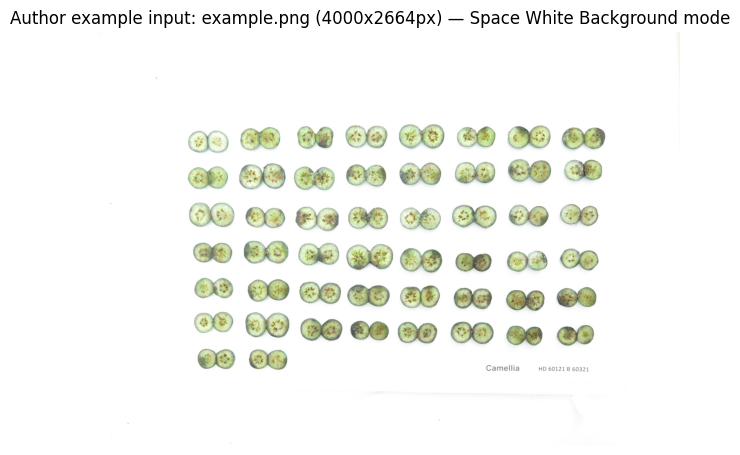

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
plt.title(f"Author example input: example.png ({w}x{h}px) — Space {BACKGROUND_MODE} mode")
plt.axis("off")
plt.show()


## 4. Input preview

Display the actual example photograph before any analysis (paper §2.2: bruised berries cut in half, photographed). This is the exact input the pipeline below will process.

**日本語:** 解析前に著者提供の入力画像を表示します（論文 §2.2 の半割り撮影画像）。



In [ ]:
WEIGHT_SPECS = {
    "blueberry_detectionv2.pt":    (22_521_196, "fc20197d090d08943bf6682bfee6028bf93250674846c24bc41744cd4464793c"),
    "blueberry_segmentationv2.pt": (23_850_130, "93d0801e85045e3cd5148593acb75ff75ff1062e689343479a45d225c3042d69"),
    "bruise_segmentationv2.pt":    (20_518_695, "46544228eae9bed24460c4aec85ca71634b0eb85d38f20f192503f8c364892c6"),
    "blueberry_detection.pt":      (22_539_350, "4ef7e9901f153a60e30d809d2266a5764bf5f56972ac98b13a8a608be3867f35"),
    "blueberry_segmentation.pt":   (23_879_103, "33cd46cbcad52a54c327dfd4458bacbc36acd918459e6b0979b6dd1c5e01501f"),
    "bruise_segmentation.pt":      (20_545_446, "1258888c065fa996ff7a7e7256453784cd0856145e37ae12c1c034d5114d41d3"),
}
weight_paths = {name: fetch(name, *WEIGHT_SPECS[name]) for name in WEIGHTS}

from ultralytics import YOLO

MODELS = {}
for name, path in weight_paths.items():
    model = YOLO(str(path))  # loads the pickle; fails loudly on incompatible payloads
    MODELS[name] = model
    n_cls = len(model.names) if getattr(model, "names", None) else -1
    print(f"loaded {name}: task={model.task}, classes={n_cls}, device will be {DEVICE}")


downloading https://huggingface.co/spaces/c-tan/blueberrybruisingdet/resolve/main/blueberry_detection.pt


OK blueberry_detection.pt: 22,539,350 bytes, sha256 verified
downloading https://huggingface.co/spaces/c-tan/blueberrybruisingdet/resolve/main/blueberry_segmentation.pt


OK blueberry_segmentation.pt: 23,879,103 bytes, sha256 verified
downloading https://huggingface.co/spaces/c-tan/blueberrybruisingdet/resolve/main/bruise_segmentation.pt


OK bruise_segmentation.pt: 20,545,446 bytes, sha256 verified


loaded blueberry_detection.pt: task=detect, classes=1, device will be cpu
loaded blueberry_segmentation.pt: task=segment, classes=1, device will be cpu
loaded bruise_segmentation.pt: task=segment, classes=1, device will be cpu


## 5. Trained weights for the selected mode

Download the three checkpoints the Space uses for the selected background mode (≈ 20–24 MB each; the mode not selected is not downloaded) and verify each against its recorded SHA-256. `YOLO(...)` then loads each pickle — this is the compatibility check for the `ultralytics.nn.*` import graph, and we report the task and class count without dumping weights.

**日本語:** 選択モードで使う 3 つの重み（各約 20–24 MB）のみを Space から取得し SHA-256 検証してから `YOLO()` で読み込みます。未選択モードの重みはダウンロードしません。

In [ ]:
import cv2
import numpy as np
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Tuple

APP_DIR = DATA_DIR  # adaptation: weights live in /content, not the Space's app directory

# VERBATIM from the author's app.py (HF Space c-tan/blueberrybruisingdet, accessed 2026-10-07),
# except MODEL_PATHS base directory and explicit device placement (both documented above).
BACKGROUND_BLACK = "Black Background"
BACKGROUND_WHITE = "White Background"

MODEL_PATHS = {
    BACKGROUND_BLACK: {
        "detection": APP_DIR / "blueberry_detectionv2.pt",
        "fruit_segmentation": APP_DIR / "blueberry_segmentationv2.pt",
        "bruise_segmentation": APP_DIR / "bruise_segmentationv2.pt",
    },
    BACKGROUND_WHITE: {
        "detection": APP_DIR / "blueberry_detection.pt",
        "fruit_segmentation": APP_DIR / "blueberry_segmentation.pt",
        "bruise_segmentation": APP_DIR / "bruise_segmentation.pt",
    },
}


class ModelManager:
    def __init__(self) -> None:
        self._cache: Dict[str, YOLO] = {}

    def get(self, model_path: Path) -> YOLO:
        model_path = model_path.resolve()
        if not model_path.exists():
            raise FileNotFoundError(f"Required model weights were not found: {model_path.name}")
        key = str(model_path)
        if key not in self._cache:
            self._cache[key] = YOLO(str(model_path))
        return self._cache[key]


MODEL_MANAGER = ModelManager()

def ensure_rgb_image(image: Any) -> np.ndarray:
    if image is None:
        raise ValueError("Please upload an image before running the analysis.")
    array = np.asarray(image)
    if array.size == 0:
        raise ValueError("The uploaded image is empty. Please choose a valid image.")
    if array.ndim == 2:
        array = cv2.cvtColor(array, cv2.COLOR_GRAY2RGB)
    elif array.ndim == 3 and array.shape[2] == 4:
        array = cv2.cvtColor(array, cv2.COLOR_RGBA2RGB)
    elif array.ndim != 3 or array.shape[2] != 3:
        raise ValueError("Unsupported image format. Please upload an RGB image.")
    return array.astype(np.uint8)


def to_bgr(image_rgb: np.ndarray) -> np.ndarray:
    return cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)


def clamp_bbox(bbox: Sequence[float], image_shape: Sequence[int], padding: int = 0) -> Tuple[int, int, int, int]:
    h, w = image_shape[:2]
    x1, y1, x2, y2 = [int(round(v)) for v in bbox]
    x1 = max(0, x1 - padding)
    y1 = max(0, y1 - padding)
    x2 = min(w, x2 + padding)
    y2 = min(h, y2 + padding)
    if x2 <= x1 or y2 <= y1:
        raise ValueError("Invalid bounding box.")
    return x1, y1, x2, y2


def safe_union_mask(result: Any, target_shape: Tuple[int, int], class_filter: Optional[int] = None) -> Optional[np.ndarray]:
    if result is None or len(result) == 0:
        return None
    prediction = result[0]
    if prediction.masks is None:
        return None
    masks = prediction.masks.data.cpu().numpy()
    if masks.size == 0:
        return None
    if class_filter is not None and prediction.boxes is not None and prediction.boxes.cls is not None:
        classes = prediction.boxes.cls.cpu().numpy().astype(int)
        masks = masks[classes == class_filter]
        if masks.size == 0:
            return None
    union_mask = np.any(masks > 0, axis=0).astype(np.uint8)
    resized = cv2.resize(union_mask, (target_shape[1], target_shape[0]), interpolation=cv2.INTER_NEAREST)
    return (resized > 0).astype(np.uint8)


def compute_centroid(mask: np.ndarray, bbox: Sequence[int]) -> Tuple[float, float]:
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        x1, y1, x2, y2 = bbox
        return ((x1 + x2) / 2.0, (y1 + y2) / 2.0)
    return (float(xs.mean()), float(ys.mean()))

def reorder_instances_reading_order(instances: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    if not instances:
        return []
    heights = [max(1, inst["bbox"][3] - inst["bbox"][1]) for inst in instances]
    row_tolerance = max(20.0, float(np.median(heights)) * 0.6)
    ordered = sorted(instances, key=lambda inst: (inst["centroid"][1], inst["centroid"][0]))
    rows: List[Dict[str, Any]] = []
    for inst in ordered:
        cy = inst["centroid"][1]
        matched_row = None
        for row in rows:
            if abs(cy - row["y"]) <= row_tolerance:
                matched_row = row
                break
        if matched_row is None:
            rows.append({"y": cy, "items": [inst]})
        else:
            matched_row["items"].append(inst)
            matched_row["y"] = float(np.mean([item["centroid"][1] for item in matched_row["items"]]))
    final_instances: List[Dict[str, Any]] = []
    for row in sorted(rows, key=lambda entry: entry["y"]):
        for inst in sorted(row["items"], key=lambda item: item["centroid"][0]):
            final_instances.append(inst)
    for idx, inst in enumerate(final_instances, start=1):
        inst["id"] = idx
    return final_instances

## 6. The author's inference pipeline (verbatim port)

Copy the Space's `app.py` helper functions **verbatim** (HF Space `c-tan/blueberrybruisingdet`, file `app.py` accessed 2026-10-07): the model cache (`ModelManager`), RGB/BGR handling, bbox clamping, union-mask resizing, centroid computation, and reading-order instance re-numbering. Only two documented changes are made elsewhere: `MODEL_PATHS` points to `/content/blueberry_bruising` instead of the Space's app directory, and the three `.predict(...)` calls receive the explicit `DEVICE` chosen in section 1 (the Space relies on ultralytics auto-selection, which resolves to the same device on each runtime).

**日本語:** 著者の `app.py` からヘルパー関数を一字一句そのまま転載します。変更は「重みの基準ディレクトリを `/content` へ」「`predict` に明示的に `DEVICE` を渡す」の 2 点のみです。

In [ ]:
import time

# VERBATIM from app.py (see notice above); only device=DEVICE added to the .predict calls.
def build_instances_yolo(image_bgr: np.ndarray, background_mode: str) -> Tuple[List[Dict[str, Any]], List[str]]:
    config = MODEL_PATHS[background_mode]
    detection_model = MODEL_MANAGER.get(config["detection"])
    segmentation_model = MODEL_MANAGER.get(config["fruit_segmentation"])
    detections = detection_model.predict(image_bgr, imgsz=640, conf=0.5, verbose=False, device=DEVICE)
    if not detections or detections[0].boxes is None or len(detections[0].boxes) == 0:
        return [], ["No fruit was detected in the uploaded image."]

    instances: List[Dict[str, Any]] = []
    warnings: List[str] = []
    for detector_index, bbox in enumerate(detections[0].boxes.xyxy.cpu().numpy(), start=1):
        try:
            x1, y1, x2, y2 = clamp_bbox(bbox, image_bgr.shape, padding=8)
            berry_roi = image_bgr[y1:y2, x1:x2]
            if berry_roi.size == 0:
                warnings.append(f"Skipped detector box {detector_index} because the cropped ROI was empty.")
                continue
            segmentation_result = segmentation_model.predict(berry_roi, imgsz=640, conf=0.5, iou=0.7, verbose=False, device=DEVICE)
            roi_mask = safe_union_mask(segmentation_result, berry_roi.shape[:2])
            if roi_mask is None or np.sum(roi_mask) == 0:
                warnings.append(f"Skipped detector box {detector_index} because fruit segmentation failed.")
                continue
            full_mask = np.zeros(image_bgr.shape[:2], dtype=np.uint8)
            full_mask[y1:y2, x1:x2] = roi_mask
            ys, xs = np.where(full_mask > 0)
            if len(xs) == 0:
                warnings.append(f"Skipped detector box {detector_index} because the generated fruit mask was empty.")
                continue
            tight_bbox = (int(xs.min()), int(ys.min()), int(xs.max()) + 1, int(ys.max()) + 1)
            instances.append(
                {
                    "bbox": tight_bbox,
                    "mask": full_mask,
                    "centroid": compute_centroid(full_mask, tight_bbox),
                }
            )
        except Exception as exc:
            warnings.append(f"Skipped detector box {detector_index} because segmentation failed: {exc}")
    return instances, warnings

def analyze_bruising(
    image_bgr: np.ndarray,
    fruit_instances: List[Dict[str, Any]],
    background_mode: str,
) -> Tuple[List[Dict[str, Any]], List[str]]:
    config = MODEL_PATHS[background_mode]
    bruise_model = MODEL_MANAGER.get(config["bruise_segmentation"])
    analyzed: List[Dict[str, Any]] = []
    warnings: List[str] = []
    for fruit in fruit_instances:
        fruit_id = fruit["id"]
        x1, y1, x2, y2 = clamp_bbox(fruit["bbox"], image_bgr.shape, padding=4)
        berry_roi = image_bgr[y1:y2, x1:x2]
        fruit_mask_roi = fruit["mask"][y1:y2, x1:x2].astype(np.uint8)
        empty_bruise_mask = np.zeros(image_bgr.shape[:2], dtype=np.uint8)
        enriched = dict(fruit)
        if berry_roi.size == 0 or np.sum(fruit_mask_roi) == 0:
            warnings.append(f"Berry {fruit_id} was skipped because the fruit ROI was empty.")
            enriched.update(
                {
                    "fruit_area": int(np.sum(fruit["mask"] > 0)),
                    "bruise_area": 0,
                    "bruise_ratio": 0.0,
                    "bruise_mask": empty_bruise_mask,
                }
            )
            analyzed.append(enriched)
            continue
        try:
            bruise_results = bruise_model.predict(berry_roi, imgsz=640, conf=0.25, iou=0.7, verbose=False, device=DEVICE)
            bruise_mask_roi = safe_union_mask(bruise_results, berry_roi.shape[:2], class_filter=0)
            if bruise_mask_roi is None:
                bruise_mask_roi = np.zeros(berry_roi.shape[:2], dtype=np.uint8)
            bruise_mask_roi[fruit_mask_roi == 0] = 0
            bruise_mask = np.zeros(image_bgr.shape[:2], dtype=np.uint8)
            bruise_mask[y1:y2, x1:x2] = bruise_mask_roi
            fruit_area = int(np.sum(fruit["mask"] > 0))
            bruise_area = int(np.sum(bruise_mask > 0))
            bruise_ratio = float(bruise_area / fruit_area) if fruit_area > 0 else 0.0
            enriched.update(
                {
                    "fruit_area": fruit_area,
                    "bruise_area": bruise_area,
                    "bruise_ratio": bruise_ratio,
                    "bruise_mask": bruise_mask,
                }
            )
            analyzed.append(enriched)
        except Exception as exc:
            warnings.append(f"Berry {fruit_id} bruising segmentation failed: {exc}")
            enriched.update(
                {
                    "fruit_area": int(np.sum(fruit["mask"] > 0)),
                    "bruise_area": 0,
                    "bruise_ratio": 0.0,
                    "bruise_mask": empty_bruise_mask,
                }
            )
            analyzed.append(enriched)
    return analyzed, warnings

def render_results(image_bgr: np.ndarray, fruit_instances: List[Dict[str, Any]]) -> np.ndarray:
    overlay = image_bgr.copy()
    fruit_pixels = np.zeros(image_bgr.shape[:2], dtype=bool)
    bruise_pixels = np.zeros(image_bgr.shape[:2], dtype=bool)
    for fruit in fruit_instances:
        fruit_pixels |= fruit["mask"] > 0
        bruise_pixels |= fruit["bruise_mask"] > 0
    green = np.zeros_like(image_bgr)
    green[:, :, 1] = 255
    red = np.zeros_like(image_bgr)
    red[:, :, 2] = 255
    overlay[fruit_pixels] = cv2.addWeighted(overlay[fruit_pixels], 0.5, green[fruit_pixels], 0.5, 0)
    overlay[bruise_pixels] = cv2.addWeighted(overlay[bruise_pixels], 0.5, red[bruise_pixels], 0.5, 0)

    for fruit in fruit_instances:
        x1, y1, x2, y2 = fruit["bbox"]
        label_y = y1 - 10 if y1 > 20 else y1 + 25
        cv2.rectangle(overlay, (x1, y1), (x2, y2), (255, 0, 0), 3)
        cv2.putText(
            overlay,
            f"Berry {fruit['id']}: {fruit['bruise_ratio']:.2f}",
            (x1, label_y),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (255, 0, 0),
            2,
            cv2.LINE_AA,
        )
    return cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)


def build_table_rows(
    fruit_instances: List[Dict[str, Any]],
) -> List[List[Any]]:
    rows: List[List[Any]] = []
    for fruit in fruit_instances:
        rows.append(
            [
                fruit["id"],
                round(fruit["bruise_ratio"], 4),
                fruit["fruit_area"],
                fruit["bruise_area"],
            ]
        )
    return rows

**Cell role:** the core pipeline, copied verbatim from `app.py`:

1. `build_instances_yolo` — YOLOv8 detection (`imgsz=640, conf=0.5`) finds berries; each detector box (padded 8 px) is cropped and passed to the YOLOv8-seg fruit model (`conf=0.5, iou=0.7`); the union fruit mask is mapped back to full-image coordinates.
2. `analyze_bruising` — each fruit's tight ROI is passed to the YOLO11-seg bruise model (`conf=0.25, iou=0.7`, class 0), the bruise mask is clipped to the fruit mask, and `bruise_ratio = bruise_area / fruit_area` (paper §2.5/§3.3 definition) is computed per berry.
3. `render_results` / `build_table_rows` — the green-fruit / red-bruise overlay with blue boxes and `Berry i: ratio` labels exactly as the Space displays, plus the result rows.

**日本語:** 論文 §2.4–2.5 に対応する推論本体です。検出（conf 0.5）→ 果実セグメンテーション（conf 0.5, iou 0.7）→ 褐変セグメンテーション（conf 0.25, iou 0.7, class 0）→ `褐変面積/果実面積` の比率計算、という著者コードをそのまま実行します。

In [ ]:
t0 = time.time()
instances, warnings_ = build_instances_yolo(image_bgr, BACKGROUND_MODE)
t_detect_seg = time.time()
print(f"fruit instances: {len(instances)} in {t_detect_seg - t0:.1f}s")
if warnings_:
    print("warnings:", *warnings_, sep="\n  ")
assert instances, "No fruit instances were produced; see warnings above."

instances = reorder_instances_reading_order(instances)
instances, bruise_warnings = analyze_bruising(image_bgr, instances, BACKGROUND_MODE)
t_total = time.time()
if bruise_warnings:
    print("bruise warnings:", *bruise_warnings, sep="\n  ")
print(f"bruising analysis done in {t_total - t_detect_seg:.1f}s (total {t_total - t0:.1f}s, device={DEVICE})")


fruit instances: 50 in 36.4s


bruising analysis done in 21.5s (total 57.9s, device=cpu)


### Run the pipeline on the example image

Execute detection → fruit segmentation → reading-order renumbering → bruising analysis, timing each stage. Any per-instance warnings from the author's code (e.g. a detector box whose segmentation failed) are reported rather than silently dropped.

**日本語:** 例画像に対しパイプラインを実行し、段階ごとの時間と警告を表示します。

In [ ]:
annotated = render_results(image_bgr, instances)
rows = build_table_rows(instances)

import pandas as pd

df = pd.DataFrame(rows, columns=["Berry ID", "Bruising Ratio", "Fruit Area", "Bruise Area"])
csv_path = DATA_DIR / "bruise_results.csv"
df.to_csv(csv_path, index=False)
print(f"per-berry bruising ratios (n={len(df)}); mean={df['Bruising Ratio'].mean():.4f}, "
      f"max={df['Bruising Ratio'].max():.4f}  (ratio = bruise px / fruit px)")
display(df)
print("CSV saved to", csv_path)


per-berry bruising ratios (n=50); mean=0.1229, max=0.3654  (ratio = bruise px / fruit px)


,Berry ID,Bruising Ratio,Fruit Area,Bruise Area
0,1,0.0382,28027,1070
1,2,0.0905,28097,2543
2,3,0.1293,25402,3285
3,4,0.0394,31322,1233
4,5,0.0000,34654,0
5,6,0.1339,25020,3351
6,7,0.1003,30866,3097
7,8,0.3101,30402,9429
8,9,0.1855,29605,5492
9,10,0.1153,38611,4450


CSV saved to /content/blueberry_bruising/bruise_results.csv


## 7. Results — bruising-ratio table and CSV

Render the author's overlay and build the per-berry result table (Berry ID, Bruising Ratio, Fruit Area, Bruise Area — the same columns the Space exports) and save `bruise_results.csv` under `/content`. The ratio is dimensionless (pixel-area fraction).

**日本語:** Space と同じ列構成の果実ごとの結果表を作成し、CSV に保存します。比率は無次元（画素面積比）です。

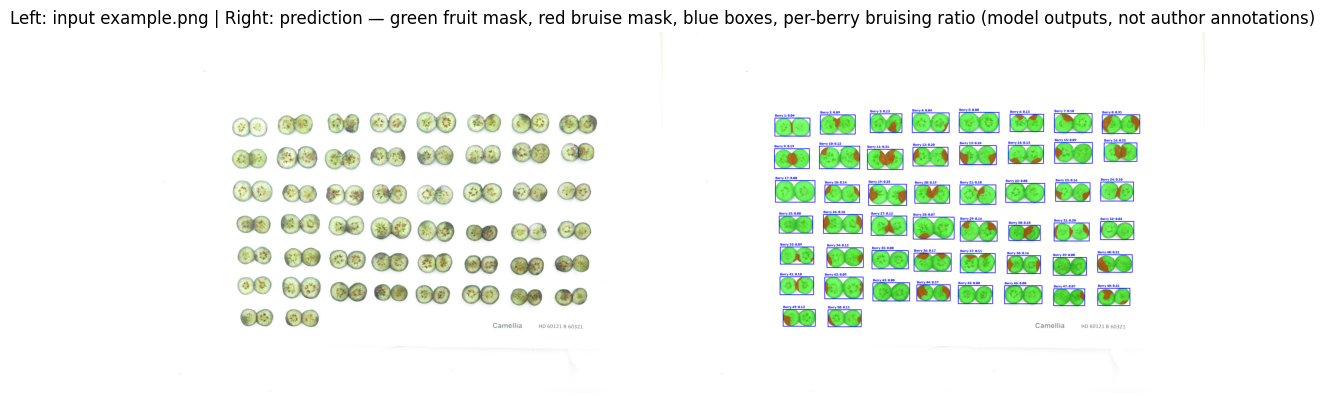

In [ ]:
side_by_side = np.hstack([
    cv2.resize(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB), (w // 2, h // 2)),
    cv2.resize(annotated, (w // 2, h // 2)),
])
fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(side_by_side)
ax.set_title("Left: input example.png | Right: prediction — green fruit mask, red bruise mask, "
             "blue boxes, per-berry bruising ratio (model outputs, not author annotations)")
ax.axis("off")
plt.savefig(DATA_DIR / "bruising_results_overlay.png", dpi=150, bbox_inches="tight")
plt.show()


### Overlay visualization (input vs prediction)

Show the original photograph next to the pipeline's annotated output (green = fruit cross-section mask, red = predicted bruise mask, blue = detection box, label = `Berry id: ratio`). These colors follow the author's `render_results`; they are model predictions, not reference annotations.

**日本語:** 左に入力画像、右に緑＝果実マスク・赤＝褐変マスク・青＝検出ボックスの予測結果オーバーレイを並べて表示します（著者の `render_results` の配色のまま）。これらはモデル予測であり、正解アノテーションではありません。

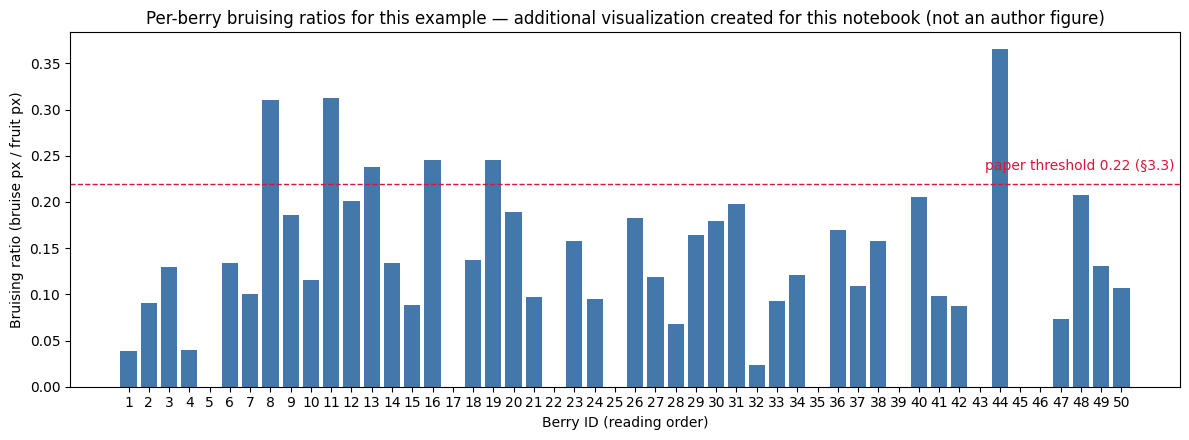

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(df["Berry ID"].astype(str), df["Bruising Ratio"], color="#4477aa")
ax.axhline(0.22, color="crimson", linestyle="--", linewidth=1)
ax.text(0.995, 0.235, "paper threshold 0.22 (§3.3)", color="crimson", ha="right", transform=ax.get_yaxis_transform())
ax.set_xlabel("Berry ID (reading order)")
ax.set_ylabel("Bruising ratio (bruise px / fruit px)")
ax.set_title("Per-berry bruising ratios for this example — additional visualization created for this notebook (not an author figure)")
plt.tight_layout()
plt.savefig(DATA_DIR / "bruising_ratios_bar.png", dpi=150, bbox_inches="tight")
plt.show()


### Per-berry bruising ratios

Bar chart of the predicted ratios for this single example, with the paper's reported resistant/susceptible threshold of 0.22 (§3.3, from k-means on cultivar means) as a reference line. This plot is an added visualization for this notebook — a single example supports no cultivar-level or statistical claim.

**日本語:** この 1 例の果実ごとの褐変比率バー charts（付加的な可視化）です。破線は論文 §3.3 のしきい値 0.22（ cultivar 平均への k-means から得られた参考値）です。1 例から統計的結論は導きません。

## 8. Interpretation, scope and references

**What was executed:** the author's published three-model inference pipeline (YOLOv8 detection → YOLOv8-seg fruit segmentation → YOLO11-seg bruise segmentation → per-berry bruising ratio) ran on one author-provided example image, using the author's own parameters and mask arithmetic. The overlay and CSV above are this run's actual outputs on the runtime that produced them (see section 1 output).

**What this does and does not verify:** it reproduces the Space's per-image inference behavior, not the paper's dataset-level results (mAP 0.995 detection/fruit segmentation; bruise mAP0.5 0.940; ratio MAE 0.025 / MAPE 15.87% on the held-out test set) — those datasets are not publicly archived. A single example also supports no cultivar-level claim (k-means threshold 0.22 and firmness correlation in §3.3/3.4 used 61 cultivars × 3 years).

**Known limitations:** the paper does not report the exact YOLO model scale (n/s/m), epochs or seeds; the background-mode ↔ example pairing was resolved by runtime border-luminance detection (documented above); Space license is CC BY-NC 4.0 (non-commercial reuse of the models/code).

**References:**
- Tan et al., Front. Plant Sci. 16:1575038 (2025), doi:10.3389/fpls.2025.1575038 — §2.2–2.6 (data, annotation, models, UI), §3.3 (bruising ratios, threshold 0.22).
- HF Space `c-tan/blueberrybruisingdet` — `app.py`, `requirements.txt`, six `*.pt` checkpoints, `example.png`/`example2.jpeg` (accessed 2026-10-07).
- PhenoPaper investigation `p-44844a141a913a88054c011c6f6323cb-20261007T095323Z-3958455` used as research guidance; all parameters here were verified against the pinned author code.

**日本語:** 本ノートブックは著者公開の推論パイプラインを 1 例画像で再実行したものです。データセット全体の精度検証（mAP 等や MAPE 15.87%）は学習データ未公開のため対象外です。しきい値 0.22 や YM20_BrSt との相関は cultivar 集団解析（§3.3/3.4）であり、1 例からは結論づけられません。モデル規模（n/s/m）やエポック数等は論文に記載がなく、背景モードと例画像の対応は縁部輝度による実行時判定（上記の通り文書化済み）で解決しました。